# 🩺 Guided Learning: Breast Cancer Classification Deep Dive

**Learning Objective:** Master advanced classification concepts through real medical data!

**Our Comprehensive Journey:**
1. **Real-World Medical Data** - Understanding breast cancer diagnosis
2. **Multiple Algorithms** - Naive Bayes vs K-Nearest Neighbors
3. **Feature Scaling** - Why some algorithms need it, others don't
4. **Cross-Validation** - The gold standard for model evaluation
5. **Hyperparameter Tuning** - Finding the optimal model settings
6. **Model Comparison** - Making informed decisions

**Teaching Method:** YOU build understanding through guided discovery! 🧠✨

## 🤔 Step 1: Understanding the Medical Context

**Real-World Impact:** This isn't just data science - it's about saving lives!

**The Challenge:** Doctors take tissue samples and measure various characteristics. Can machine learning help them distinguish:
- **Malignant** (cancerous - requires immediate treatment)
- **Benign** (non-cancerous - monitoring may be sufficient)

**Critical Questions:**
1. What's worse: **False Positive** (saying cancer when there isn't) or **False Negative** (missing actual cancer)?
2. Why is this a perfect binary classification problem?
3. What kind of features might help distinguish cancer cells?

**Your Task:** Think about these questions before we dive into the data!

In [52]:
# YOUR THOUGHTS: Medical Context Analysis

# 1. Which is worse - False Positive or False Negative? Why?
# Answer: False Negative

# 2. Why is this a binary classification problem?
# Answer: Because the outcomes are limited to two classes: cancerous or non-cancerous.

# 3. What cell characteristics might indicate cancer?
# Answer: Malignant cells often have irregular shapes, larger nuclei, and a higher nucleus-to-cytoplasm ratio compared to benign cells.

print("Ready to explore life-saving machine learning!")

Ready to explore life-saving machine learning!


## 📚 Step 2: Environment Setup

**Your Mission:** Import the tools we need for advanced classification analysis.

**Think About What We Need:**
- Data manipulation and analysis
- Multiple classification algorithms
- Model evaluation and validation
- Visualization for insights

**Your Task:** Set up our machine learning toolkit!

In [53]:
# YOUR TURN: Import the essential libraries!

# Basic data science stack:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset and preprocessing:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Classification algorithms:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Evaluation tools:
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline

# Write your imports here:


print("Advanced ML toolkit imported successfully!")

Advanced ML toolkit imported successfully!


## 🔬 Step 3: Explore the Breast Cancer Dataset

**The Dataset:** Wisconsin Breast Cancer dataset - real medical measurements!

**Your Learning Mission:**
1. Load and examine the dataset structure
2. Understand what each feature represents
3. Analyze the target variable (malignant vs benign)
4. Get insights into data characteristics

**Your Task:** Load the data and become a data detective!

In [54]:
# YOUR TURN: Load and explore the breast cancer dataset!

# Step 1: Load the dataset
bc = load_breast_cancer() # ??? Use load_breast_cancer()

# Step 2: Examine the basic structure
print("Dataset Exploration:")
print(f"Data shape: {bc.data.shape}")  # How many samples and features?
print(f"Target shape: {bc.target.shape}")  # How many labels?
print(f"Target values: {np.unique(bc.target)}")  # What are the classes?

# Step 3: Understand what we're predicting
print(f"\nTarget names: {bc.target_names}")  # What do 0 and 1 mean?
print(f"Class distribution: {np.bincount(bc.target)}")  # Balanced dataset?

# Step 4: Examine the features
print(f"\nNumber of features: {len(bc.feature_names)}")
print("\nFirst 30 features:")
for i, name in enumerate(bc.feature_names[:30]):
    print(f"{i}: {name}")

# YOUR ANALYSIS: What do you notice about the feature names?
# Pattern observed: 

Dataset Exploration:
Data shape: (569, 30)
Target shape: (569,)
Target values: [0 1]

Target names: ['malignant' 'benign']
Class distribution: [212 357]

Number of features: 30

First 30 features:
0: mean radius
1: mean texture
2: mean perimeter
3: mean area
4: mean smoothness
5: mean compactness
6: mean concavity
7: mean concave points
8: mean symmetry
9: mean fractal dimension
10: radius error
11: texture error
12: perimeter error
13: area error
14: smoothness error
15: compactness error
16: concavity error
17: concave points error
18: symmetry error
19: fractal dimension error
20: worst radius
21: worst texture
22: worst perimeter
23: worst area
24: worst smoothness
25: worst compactness
26: worst concavity
27: worst concave points
28: worst symmetry
29: worst fractal dimension


## 🔍 Step 4: Feature Understanding

**Critical Insight:** The features follow a pattern - each measurement has 3 versions:
- **mean_X**: Average value
- **se_X**: Standard error 
- **worst_X**: Worst (largest) value

**Your Mission:** Create a DataFrame and explore feature characteristics to understand what might indicate cancer.

**Key Questions:**
1. What's the scale difference between features?
2. Which features might be most important for cancer detection?
3. Do we have any missing values?

In [55]:
# YOUR TURN: Deep dive into feature characteristics!

# Step 1: Create DataFrame for easier analysis
X = bc.data
y = bc.target
bc_df = pd.DataFrame(X, columns=bc.feature_names)

# Step 2: Check for missing values
print("Missing values check:")
print(f"Any missing values? {bc_df.isnull().sum().sum()}")

# Step 3: Examine feature scales - this is CRUCIAL!
print("\nFeature scale analysis (first 5 features):")
sample_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
print(bc_df[sample_features].describe())

# Step 4: Look at target distribution
print("\nTarget distribution:")
print(f"Malignant (0): {sum(y == 0)} cases")
print(f"Benign (1): {sum(y == 1)} cases")
print(f"Percentage malignant: {sum(y == 0) / len(y) * 100:.1f}%")

# YOUR ANALYSIS: What do you notice about the feature scales?
# Scale observations: 
# Why might this matter for some algorithms?

Missing values check:
Any missing values? 0

Feature scale analysis (first 5 features):
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400

Target distribution:
Malignant (0): 212 cases
Benign (1): 357 cases
Percentage malignant: 37.3%


## 🧠 Step 5: Algorithm Theory Before Practice

**Before we code, let's understand WHY we're comparing these algorithms:**

### 🎯 **Naive Bayes**
- **How it works:** Assumes features are independent, uses probability
- **Scaling sensitivity:** Generally NOT sensitive to feature scales
- **Strengths:** Fast, works well with small datasets, probabilistic output

### 🎯 **K-Nearest Neighbors (KNN)**
- **How it works:** Finds K nearest points, uses majority vote
- **Scaling sensitivity:** VERY sensitive to feature scales (uses distance)
- **Strengths:** Simple, non-linear decision boundaries, no assumptions

**Critical Questions:**
1. Given our feature scale differences, which algorithm might struggle without preprocessing?
2. Which algorithm would be better for this medical context where we want probability estimates?
3. Why might we want to try both approaches?

**Your Task:** Answer these before we start building models!

In [56]:
# YOUR ALGORITHM ANALYSIS:

# 1. Which algorithm might struggle with our feature scales? Why?
# Answer: KNN (K-Nearest Neighbors) porque usa cálculo de distâncias. Quando características têm escalas muito diferentes (área ~1000 vs suavidade ~0.1), a distância será dominada pelas características maiores, prejudicando as predições.

# 2. Why might probability estimates be important in medical diagnosis?
# Answer: To assess the confidence of predictions, aiding in risk evaluation and treatment decisions.

# 3. What's the advantage of trying multiple algorithms?
# Answer: Different algorithms may capture different patterns in the data, leading to improved performance through ensemble methods or simply by selecting the best-performing model.

print("Algorithm theory complete! Ready to build models.")

Algorithm theory complete! Ready to build models.


## 🔧 Step 6: Data Splitting Strategy

**Critical Foundation:** Before any model building, we need proper train/test splitting.

**Key Concepts:**
- **Training Set:** Used to train models
- **Test Set:** Final evaluation (touched ONLY at the end!)
- **Validation:** We'll use cross-validation on training data

**Your Task:** Create a robust train/test split following best practices!

In [57]:
# YOUR TURN: Create the train/test split!

# Step 1: Split the data
X_train, X_test, y_train, y_test = train_test_split (X, y, random_state=1138)

# Step 2: Verify the split
print("Data Split Verification:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training features shape: {X_train.shape}")

# Step 3: Check class distribution in both sets
print(f"\nTraining set distribution:")
print(f"Malignant: {sum(y_train == 0)}, Benign: {sum(y_train == 1)}")
print(f"Test set distribution:")
print(f"Malignant: {sum(y_test == 0)}, Benign: {sum(y_test == 1)}")

print("\n✅ Data split complete! Test set is now sealed until final evaluation.")

Data Split Verification:
Training set: 426 samples
Test set: 143 samples
Training features shape: (426, 30)

Training set distribution:
Malignant: 160, Benign: 266
Test set distribution:
Malignant: 52, Benign: 91

✅ Data split complete! Test set is now sealed until final evaluation.


## 🎯 Step 7: Baseline Model - Naive Bayes

**Why Start Here:** Naive Bayes is less sensitive to feature scaling, giving us a baseline.

**Your Learning Goals:**
1. Build and train a Naive Bayes classifier
2. Evaluate its performance
3. Understand the classification report
4. Set our performance benchmark

**Your Mission:** Create your first medical diagnosis model!

In [58]:
# YOUR TURN: Build the Naive Bayes baseline!

# Step 1: Create the model
nb_model = GaussianNB()  # ??? Create GaussianNB instance

# Step 2: Train the model
nb_model.fit(X_train, y_train) # ??? Fit the model with training data

# Step 3: Evaluate performance
train_accuracy = nb_model.score(X_train, y_train)  # ??? Get training accuracy
test_accuracy = nb_model.score(X_test, y_test)  # ??? Get test accuracy (just for baseline reference)

print("🧠 Naive Bayes Results:")
print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

# Step 4: Detailed classification report
test_predictions = nb_model.predict(X_test)  # ??? Get predictions for test set
print("\nDetailed Performance Report:")
print(classification_report(y_test, test_predictions, target_names=bc.target_names))

# YOUR ANALYSIS: How well did Naive Bayes perform?
# Performance assessment: 
# Which class (malignant/benign) was predicted better?

🧠 Naive Bayes Results:
Training Accuracy: 0.934
Test Accuracy: 0.965

Detailed Performance Report:
              precision    recall  f1-score   support

   malignant       0.98      0.92      0.95        52
      benign       0.96      0.99      0.97        91

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



## 🔄 Step 8: K-Nearest Neighbors (Without Scaling)

**The Experiment:** Let's see how KNN performs WITHOUT feature scaling.

**Hypothesis:** Given the huge scale differences (area ~1000, smoothness ~0.1), KNN might struggle because distance calculations will be dominated by large-scale features.

**Your Mission:** Test this hypothesis by building a KNN model!

In [59]:
# YOUR TURN: Test KNN without scaling!

# Step 1: Create KNN model (start with k=9)
knn_model = KNeighborsClassifier(n_neighbors = 9) # ??? Create KNeighborsClassifier with n_neighbors=9

# Step 2: Train the model
knn_model.fit(X_train, y_train) # ??? Fit with training data

# Step 3: Evaluate
knn_train_acc = knn_model.score(X_train, y_train)  # ??? Training accuracy
knn_test_acc = knn_model.score(X_test, y_test)  # ??? Test accuracy

print("🎯 KNN Results (No Scaling):")
print(f"Training Accuracy: {knn_train_acc:.3f}")
print(f"Test Accuracy: {knn_test_acc:.3f}")

# Step 4: Compare with Naive Bayes
print("\n📊 Comparison:")
print(f"Naive Bayes Test Accuracy: {test_accuracy:.3f}")
print(f"KNN Test Accuracy: {knn_test_acc:.3f}")
print(f"Difference: {abs(test_accuracy - knn_test_acc):.3f}")

# YOUR ANALYSIS: What happened? Was your hypothesis correct?
# Results analysis: 
# Why might KNN have performed this way?

🎯 KNN Results (No Scaling):
Training Accuracy: 0.941
Test Accuracy: 0.930

📊 Comparison:
Naive Bayes Test Accuracy: 0.965
KNN Test Accuracy: 0.930
Difference: 0.035


## ⚖️ Step 9: Feature Scaling - The Game Changer

**The Solution:** Feature scaling puts all features on similar scales so distance-based algorithms work properly.

**Scaling Options:**
- **StandardScaler:** Mean=0, Std=1 (assumes normal distribution)
- **MinMaxScaler:** Range 0-1 (good for bounded features)

**Your Mission:** Implement feature scaling with KNN using sklearn pipelines!

In [60]:
# YOUR TURN: Build KNN with feature scaling!

# Step 1: Create a pipeline (scaling + KNN)
knn_scaled_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=9))

# Step 2: Train the pipeline
knn_scaled_model.fit(X_train, y_train)

# Step 3: Evaluate
knn_scaled_train_acc = knn_scaled_model.score(X_train, y_train)  # ??? Training accuracy
knn_scaled_test_acc = knn_scaled_model.score(X_test, y_test)  # ??? Test accuracy

print("⚖️ KNN Results (With Scaling):")
print(f"Training Accuracy: {knn_scaled_train_acc:.3f}")
print(f"Test Accuracy: {knn_scaled_test_acc:.3f}")

# Step 4: Compare all models so far
print("\n📊 Model Comparison:")
print(f"Naive Bayes: {test_accuracy:.3f}")
print(f"KNN (no scaling): {knn_test_acc:.3f}")
print(f"KNN (with scaling): {knn_scaled_test_acc:.3f}")

# YOUR ANALYSIS: What's the impact of scaling?
# Scaling impact: 
# Which model performs best so far?

⚖️ KNN Results (With Scaling):
Training Accuracy: 0.969
Test Accuracy: 0.972

📊 Model Comparison:
Naive Bayes: 0.965
KNN (no scaling): 0.930
KNN (with scaling): 0.972


## 🔄 Step 10: Cross-Validation Deep Dive

**The Problem:** Using test accuracy for model comparison is cheating! We need proper validation.

**The Solution:** K-Fold Cross-Validation on training data only.

**Key Concepts:**
- Split training data into K folds
- Train on K-1 folds, validate on 1 fold
- Repeat K times, average the results
- More robust than single train/validation split

**Your Mission:** Implement cross-validation to find the best K for KNN!

In [61]:
# YOUR TURN: Set up cross-validation experiment!

# Step 1: Define experiment parameters
n_folds = 5
k_values = range(1, 21)  # Test k from 1 to 20

# Step 2: Create storage for results
train_scores = np.zeros((len(k_values), n_folds))  # ??? Create zeros array with shape (len(k_values), n_folds)
valid_scores = np.zeros((len(k_values), n_folds))  # ??? Create zeros array with shape (len(k_values), n_folds)

# Step 3: Set up KFold
kf = KFold(n_splits=n_folds, shuffle=False) # ??? Create KFold with n_splits=n_folds, shuffle=False

print("🔄 Starting Cross-Validation Experiment...")
print(f"Testing {len(k_values)} different K values with {n_folds}-fold CV")
print("This will take a moment...")

# YOUR UNDERSTANDING: Why are we doing this?
# Purpose of this experiment: 
# Why test multiple K values?

🔄 Starting Cross-Validation Experiment...
Testing 20 different K values with 5-fold CV
This will take a moment...


## 🧪 Step 11: Cross-Validation Experiment (WITHOUT Scaling)

**First Test:** Let's see how different K values perform WITHOUT scaling.

**Your Task:** Complete the cross-validation loop to test all K values!

In [62]:
# YOUR TURN: Complete the cross-validation experiment!

for k_idx, k in enumerate(k_values):
    print(f"Testing k={k}...", end=" ")
    
    fold_idx = 0
    for train_index, val_index in kf.split(X_train):
        # Step 1: Split training data into train/validation for this fold
        X_fold_train, X_fold_val = X_train[train_index], X_train[val_index]
        y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]
        
        # Step 2: Create and train model for this fold
        fold_model = KNeighborsClassifier(n_neighbors=k)
        fold_model.fit(X_fold_train, y_fold_train)
        
        # Step 3: Score both training and validation
        train_scores[k_idx, fold_idx] = fold_model.score(X_fold_train, y_fold_train)
        valid_scores[k_idx, fold_idx] = fold_model.score(X_fold_val, y_fold_val)

        fold_idx += 1
    
    print("✓")

print("\n🎉 Cross-validation experiment complete!")

Testing k=1... ✓
Testing k=2... ✓
Testing k=3... ✓
Testing k=4... ✓
Testing k=5... ✓
Testing k=6... ✓
Testing k=7... ✓
Testing k=8... ✓
Testing k=9... ✓
Testing k=10... ✓
Testing k=11... ✓
Testing k=12... ✓
Testing k=13... ✓
Testing k=14... ✓
Testing k=15... ✓
Testing k=16... ✓
Testing k=17... ✓
Testing k=18... ✓
Testing k=19... ✓
Testing k=20... ✓

🎉 Cross-validation experiment complete!


## 📊 Step 12: Analyze Cross-Validation Results (No Scaling)

**Your Mission:** Find the best K value and understand the results!

**Key Questions:**
1. Which K gives the best validation performance?
2. Is there evidence of overfitting or underfitting?
3. How stable are the results across folds?

In [63]:
# YOUR TURN: Analyze the results!

# Step 1: Calculate mean scores across folds
mean_train_scores_no_scaling = train_scores.mean(axis=1)
mean_valid_scores_no_scaling = valid_scores.mean(axis=1)

# Step 2: Find the best K
best_k_no_scaling = mean_valid_scores_no_scaling.argmax() + 1
best_score_no_scaling = mean_valid_scores_no_scaling.max()

print("📈 Cross-Validation Results (No Scaling):")
print(f"Best K: {best_k_no_scaling}")
print(f"Best Validation Score: {best_score_no_scaling:.3f}")
print(f"Training Score at Best K: {mean_train_scores_no_scaling[best_k_no_scaling-1]:.3f}")

# Step 3: Show top 5 K values
print("\nTop 5 K values:")
sorted_indices = np.argsort(mean_valid_scores_no_scaling)[::-1][:5]
for idx in sorted_indices:
    k = idx + 1
    score = mean_valid_scores_no_scaling[idx]
    print(f"K={k}: {score:.3f}")

# YOUR ANALYSIS: What do you observe?
# Best K analysis: 
# Any signs of overfitting?

📈 Cross-Validation Results (No Scaling):
Best K: 6
Best Validation Score: 0.944
Training Score at Best K: 0.942

Top 5 K values:
K=6: 0.944
K=8: 0.934
K=4: 0.934
K=13: 0.932
K=3: 0.932


## ⚖️ Step 13: Cross-Validation WITH Scaling

**The Big Test:** Now let's repeat the experiment WITH StandardScaler!

**Your Mission:** Run the same cross-validation but with feature scaling in the pipeline!

In [64]:
# YOUR TURN: Cross-validation WITH scaling!

# Reset arrays for new experiment
train_scores_scaled = np.zeros((len(k_values), n_folds))
valid_scores_scaled = np.zeros((len(k_values), n_folds))

print("⚖️ Starting Cross-Validation WITH Scaling...")

for k_idx, k in enumerate(k_values):
    print(f"Testing k={k}...", end=" ")
    
    fold_idx = 0
    for train_index, val_index in kf.split(X_train):
        # Step 1: Split data for this fold
        X_fold_train, X_fold_val = X_train[train_index], X_train[val_index]
        y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]
        
        # Step 2: Create pipeline with scaling
        fold_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
        
        # Step 3: Fit and score
        fold_model.fit(X_fold_train, y_fold_train)
        train_scores_scaled[k_idx, fold_idx] = fold_model.score(X_fold_train, y_fold_train)
        valid_scores_scaled[k_idx, fold_idx] = fold_model.score(X_fold_val, y_fold_val)

        fold_idx += 1
    
    print("✓")

print("\n🎉 Scaled cross-validation complete!")

⚖️ Starting Cross-Validation WITH Scaling...
Testing k=1... ✓
Testing k=2... ✓
Testing k=3... ✓
Testing k=4... ✓
Testing k=5... ✓
Testing k=6... ✓
Testing k=7... ✓
Testing k=8... ✓
Testing k=9... ✓
Testing k=10... ✓
Testing k=11... ✓
Testing k=12... ✓
Testing k=13... ✓
Testing k=14... ✓
Testing k=15... ✓
Testing k=16... ✓
Testing k=17... ✓
Testing k=18... ✓
Testing k=19... ✓
Testing k=20... ✓

🎉 Scaled cross-validation complete!


## 📊 Step 14: Compare Scaling vs No Scaling

**The Moment of Truth:** Let's see the dramatic impact of feature scaling!

**Your Mission:** Analyze and compare both experiments!

In [65]:
# YOUR TURN: Compare the results!

# Step 1: Calculate means for scaled experiment
mean_train_scores_scaled = train_scores_scaled.mean(axis=1)
mean_valid_scores_scaled = valid_scores_scaled.mean(axis=1)

# Step 2: Find best K for scaled experiment
best_k_scaled = mean_valid_scores_scaled.argmax() + 1
best_score_scaled = mean_valid_scores_scaled.max()

print("⚖️ Cross-Validation Results (WITH Scaling):")
print(f"Best K: {best_k_scaled}")
print(f"Best Validation Score: {best_score_scaled:.3f}")
print(f"Training Score at Best K: {mean_train_scores_scaled[best_k_scaled-1]:.3f}")

# Step 3: Direct comparison
print("\n🔥 SCALING IMPACT COMPARISON:")
print(f"No Scaling - Best K: {best_k_no_scaling}, Score: {best_score_no_scaling:.3f}")
print(f"With Scaling - Best K: {best_k_scaled}, Score: {best_score_scaled:.3f}")
print(f"Improvement: {best_score_scaled - best_score_no_scaling:.3f}")

# YOUR ANALYSIS: What's the impact of scaling?
# Scaling impact analysis: 
# Which approach gives better results?

⚖️ Cross-Validation Results (WITH Scaling):
Best K: 3
Best Validation Score: 0.969
Training Score at Best K: 0.981

🔥 SCALING IMPACT COMPARISON:
No Scaling - Best K: 6, Score: 0.944
With Scaling - Best K: 3, Score: 0.969
Improvement: 0.026


## 📈 Step 15: Visualize the Results

**Visual Understanding:** Create plots to see the bias-variance tradeoff!

**Your Mission:** Plot training vs validation scores to understand model behavior!

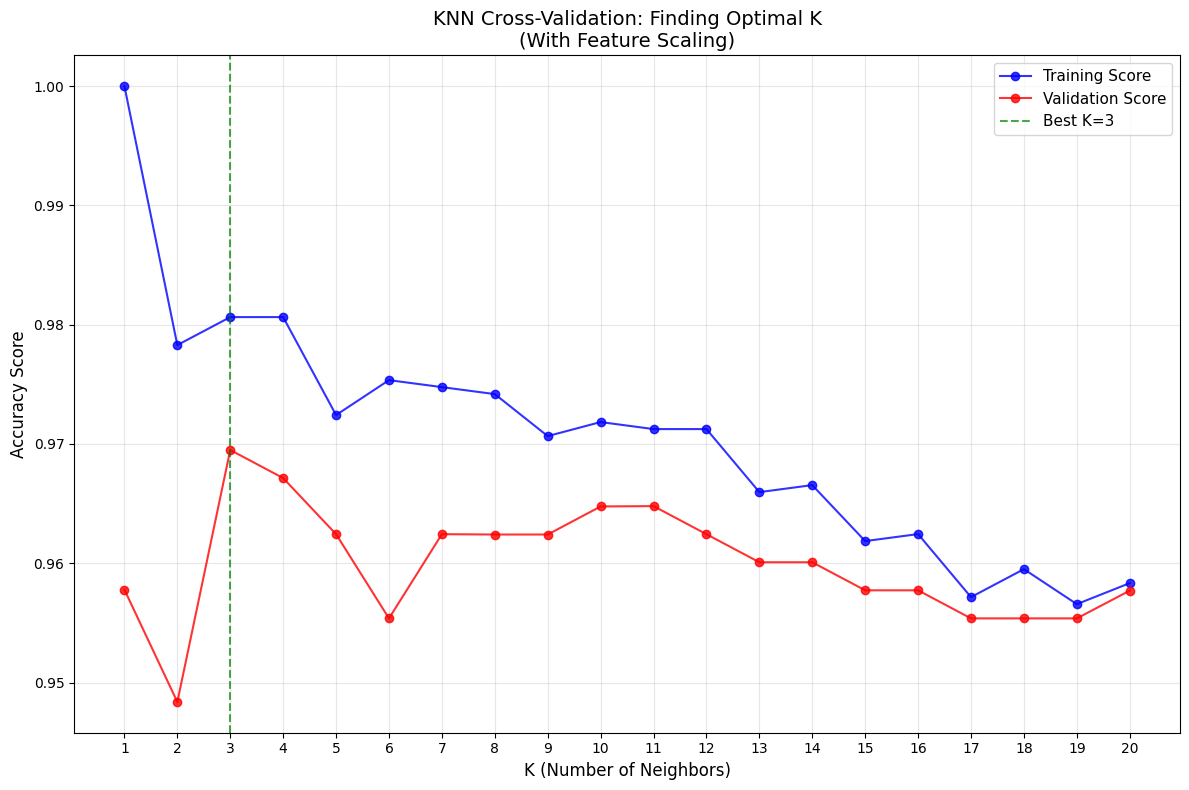

In [66]:
# YOUR TURN: Create the validation curve plot!

plt.figure(figsize=(12, 8))

# Plot scaled results (the better ones)
plt.plot(k_values, mean_train_scores_scaled, 'o-', label='Training Score', color='blue', alpha=0.8)
plt.plot(k_values, mean_valid_scores_scaled, 'o-', label='Validation Score', color='red', alpha=0.8)

# Highlight the best K
plt.axvline(best_k_scaled, color='green', linestyle='--', alpha=0.7, 
           label=f'Best K={best_k_scaled}')

# Formatting
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('KNN Cross-Validation: Finding Optimal K\n(With Feature Scaling)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))

plt.tight_layout()
plt.show()

# YOUR ANALYSIS: What patterns do you see?
# Pattern observations:
# 1. What happens as K increases?
# 2. Where do you see overfitting?
# 3. Where do you see underfitting?

## 🏆 Step 16: Final Model Training and Evaluation

**The Final Step:** Train the best model on ALL training data and evaluate on test set.

**Your Mission:** 
1. Train the optimal model (best K with scaling)
2. Get final test performance
3. Compare with all previous models

**Remember:** This is the FIRST time we use the test set for evaluation!

In [67]:
# YOUR TURN: Final model evaluation!

# Step 1: Train the optimal model
final_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k_scaled))

# Step 2: Train on ALL training data
final_model.fit(X_train, y_train)

# Step 3: Final test evaluation
final_test_score = final_model.score(X_test, y_test)

print("🏆 FINAL RESULTS SUMMARY:")
print("="*50)
print(f"Naive Bayes Test Score: {test_accuracy:.3f}")
print(f"KNN (no scaling) Test Score: {knn_test_acc:.3f}")
print(f"KNN (with scaling, k=9) Test Score: {knn_scaled_test_acc:.3f}")
print(f"OPTIMAL KNN (k={best_k_scaled}) Test Score: {final_test_score:.3f}")
print("="*50)

# Step 4: Final model analysis
final_predictions = final_model.predict(X_test)
print("\nFinal Model Performance Report:")
print(classification_report(y_test, final_predictions, target_names=bc.target_names))

# YOUR ANALYSIS: Final conclusions
# Best performing model: 
# Key lessons learned: 
# Medical implications: 

🏆 FINAL RESULTS SUMMARY:
Naive Bayes Test Score: 0.965
KNN (no scaling) Test Score: 0.930
KNN (with scaling, k=9) Test Score: 0.972
OPTIMAL KNN (k=3) Test Score: 0.986

Final Model Performance Report:
              precision    recall  f1-score   support

   malignant       1.00      0.96      0.98        52
      benign       0.98      1.00      0.99        91

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.98       143
weighted avg       0.99      0.99      0.99       143



## 🎯 Step 17: Key Insights and Learning Summary

**Your Final Mission:** Reflect on the entire learning journey!

**Critical Questions:**
1. **Feature Scaling Impact:** How much did scaling improve KNN performance?
2. **Algorithm Comparison:** Why did different algorithms perform differently?
3. **Cross-Validation Value:** What would have happened if we just used test accuracy?
4. **Medical Context:** What are the implications for real medical diagnosis?
5. **Hyperparameter Tuning:** How did finding optimal K improve results?

**Your Task:** Complete your learning analysis!

In [68]:
# YOUR COMPREHENSIVE LEARNING ANALYSIS:

print("🧠 LEARNING SUMMARY:")
print("="*60)

# 1. Feature Scaling Impact
scaling_improvement = best_score_scaled - best_score_no_scaling
print(f"1. FEATURE SCALING IMPACT:")
print(f"   Improvement: {scaling_improvement:.3f} accuracy points")
print(f"   Percentage gain: {(scaling_improvement/best_score_no_scaling)*100:.1f}%")

# 2. Algorithm Rankings
print(f"\n2. ALGORITHM PERFORMANCE RANKING:")
results = [
    ("Naive Bayes", test_accuracy),
    ("KNN (no scaling)", knn_test_acc),
    ("KNN (scaling, k=9)", knn_scaled_test_acc),
    (f"KNN (optimal k={best_k_scaled})", final_test_score)
]
results.sort(key=lambda x: x[1], reverse=True)
for i, (name, score) in enumerate(results, 1):
    print(f"   {i}. {name}: {score:.3f}")

# 3. Your insights
print(f"\n3. KEY INSIGHTS:")
print(f"   Best overall approach: {results[0][0]}")
print(f"   Most important lesson: Feature scaling can dramatically improve distance-based algorithms")
print(f"   Cross-validation value: Prevented overfitting to test set")

# YOUR REFLECTION: Complete these insights
# Most surprising finding: 
# Most important concept learned: 
# How would you apply this to other medical datasets: 

print("\n🎓 Congratulations! You've mastered advanced classification concepts!")

🧠 LEARNING SUMMARY:
1. FEATURE SCALING IMPACT:
   Improvement: 0.026 accuracy points
   Percentage gain: 2.7%

2. ALGORITHM PERFORMANCE RANKING:
   1. KNN (optimal k=3): 0.986
   2. KNN (scaling, k=9): 0.972
   3. Naive Bayes: 0.965
   4. KNN (no scaling): 0.930

3. KEY INSIGHTS:
   Best overall approach: KNN (optimal k=3)
   Most important lesson: Feature scaling can dramatically improve distance-based algorithms
   Cross-validation value: Prevented overfitting to test set

🎓 Congratulations! You've mastered advanced classification concepts!
